# Ingest experiment data

In [ ]:
import lib.experiment_oop as exp
import joblib
import lib.signalProcess as signalProcess

# # GREEN
# dPaths = ["/media/DATA/MAK/GRISZ_02/AA0001",
#           "/media/DATA/MAK/GRISZ_03/AA0001",
#           "/media/DATA/MAK/GRISZ_05/AA0001",
# ]

# # Create and load an experiment group
# group = exp.ExperimentGroup(dPaths, format = 'MAK')
# # drop rows with missing dB match
# group.df = group.df[~group.df['dB'].isna()]
# group.load_qcam_data()
# # set all to same frame length
# group.df = group.df[group.df['nFrames']==int(group.df.nFrames.mode()[0])]
# joblib.dump(group,'../data/cache/GRISZ_2-3-5_group_df.joblib')
group = joblib.load('../data/cache/GRISZ_2-3-5_group_df.joblib')


In [ ]:
experiment_idx = 0
dB = 80

experiment = group.experiments[experiment_idx]
experiment

,qcam,dir,xsg,pulse,dB,treatment
1,/media/DATA/MAK/GRISZ_02/AA0001/AA0001AAAA0017...,/media/DATA/MAK/GRISZ_02/AA0001,/media/DATA/MAK/GRISZ_02/AA0001/AA0001AAAA0017...,6-64kHz_40dB_10000msTotal_Fs250kHz,40.0,CTRL
2,/media/DATA/MAK/GRISZ_02/AA0001/AA0001AAAA0032...,/media/DATA/MAK/GRISZ_02/AA0001,/media/DATA/MAK/GRISZ_02/AA0001/AA0001AAAA0032...,6-64kHz_70dB_10000msTotal_Fs250kHz,70.0,CTRL
3,/media/DATA/MAK/GRISZ_02/AA0001/AA0001AAAA0033...,/media/DATA/MAK/GRISZ_02/AA0001,/media/DATA/MAK/GRISZ_02/AA0001/AA0001AAAA0033...,6-64kHz_30dB_10000msTotal_Fs250kHz,30.0,CTRL
4,/media/DATA/MAK/GRISZ_02/AA0001/AA0001AAAA0034...,/media/DATA/MAK/GRISZ_02/AA0001,/media/DATA/MAK/GRISZ_02/AA0001/AA0001AAAA0034...,6-64kHz_40dB_10000msTotal_Fs250kHz,40.0,CTRL
5,/media/DATA/MAK/GRISZ_02/AA0001/AA0001AAAA0035...,/media/DATA/MAK/GRISZ_02/AA0001,/media/DATA/MAK/GRISZ_02/AA0001/AA0001AAAA0035...,6-64kHz_50dB_10000msTotal_Fs250kHz,50.0,CTRL
...,...,...,...,...,...,...
89,/media/DATA/MAK/GRISZ_02/AA0001/AA0001AAAA0018...,/media/DATA/MAK/GRISZ_02/AA0001,/media/DATA/MAK/GRISZ_02/AA0001/AA0001AAAA0018...,6-64kHz_50dB_10000msTotal_Fs250kHz,50.0,CTRL
90,/media/DATA/MAK/GRISZ_02/AA0001/AA0001AAAA0019...,/media/DATA/MAK/GRISZ_02/AA0001,/media/DATA/MAK/GRISZ_02/AA0001/AA0001AAAA0019...,6-64kHz_70dB_10000msTotal_Fs250kHz,70.0,CTRL
91,/media/DATA/MAK/GRISZ_02/AA0001/AA0001AAAA0020...,/media/DATA/MAK/GRISZ_02/AA0001,/media/DATA/MAK/GRISZ_02/AA0001/AA0001AAAA0020...,6-64kHz_60dB_10000msTotal_Fs250kHz,60.0,CTRL
92,/media/DATA/MAK/GRISZ_02/AA0001/AA0001AAAA0021...,/media/DATA/MAK/GRISZ_02/AA0001,/media/DATA/MAK/GRISZ_02/AA0001/AA0001AAAA0021...,6-64kHz_80dB_10000msTotal_Fs250kHz,80.0,CTRL


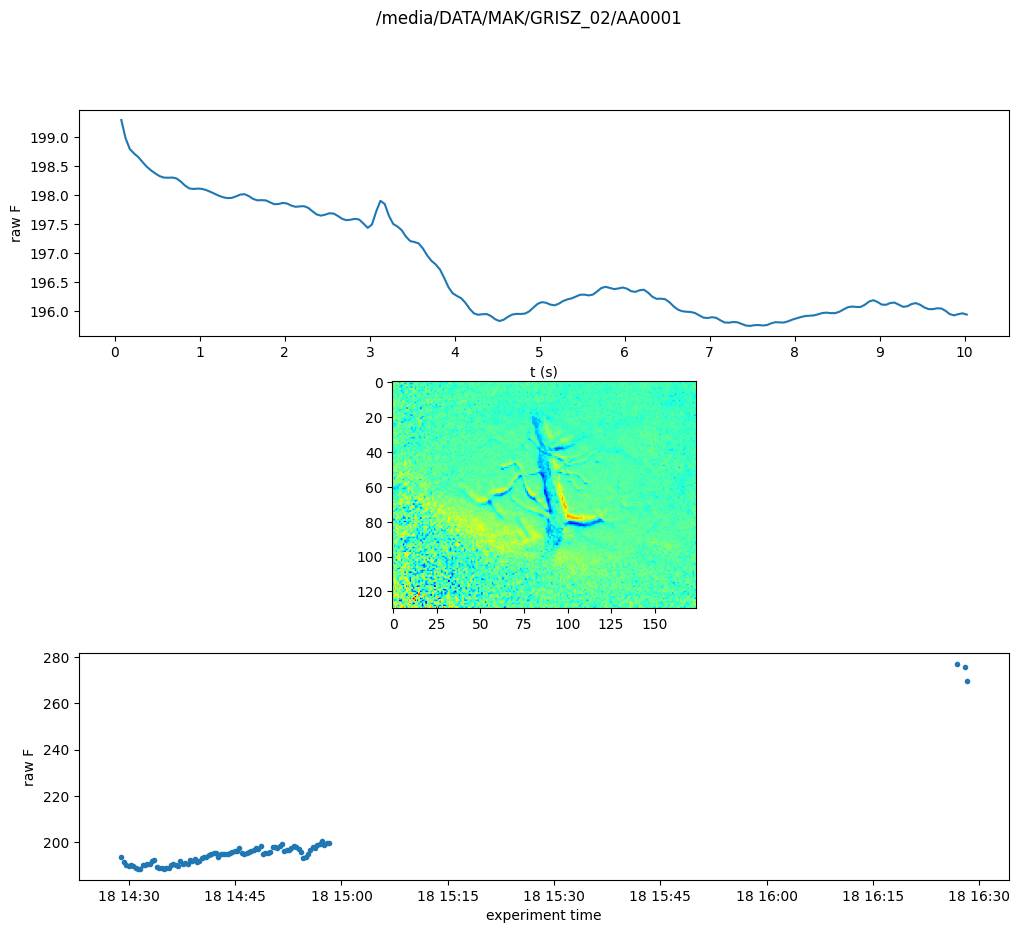

In [13]:
experiment.plot_experiment_overview()

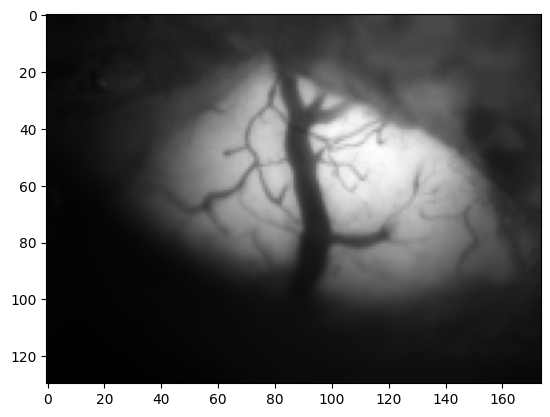

In [208]:
from operator import itemgetter
import numpy as np
import matplotlib.pyplot as plt

qcam_dB = sorted(experiment.df.loc[experiment.df['dB'] == dB, 'qcam'].tolist())
rawF = np.array(itemgetter(*qcam_dB)(experiment.qcam2img))
plt.imshow(rawF.mean(axis=(0,-1)),'gray')

# Step-by-step hierarchical clustering


## Create ROI as bins that sweep across image:

/media/DATA/MAK/GRISZ_02/AA0001/AA0001AAAA0051.qcamraw


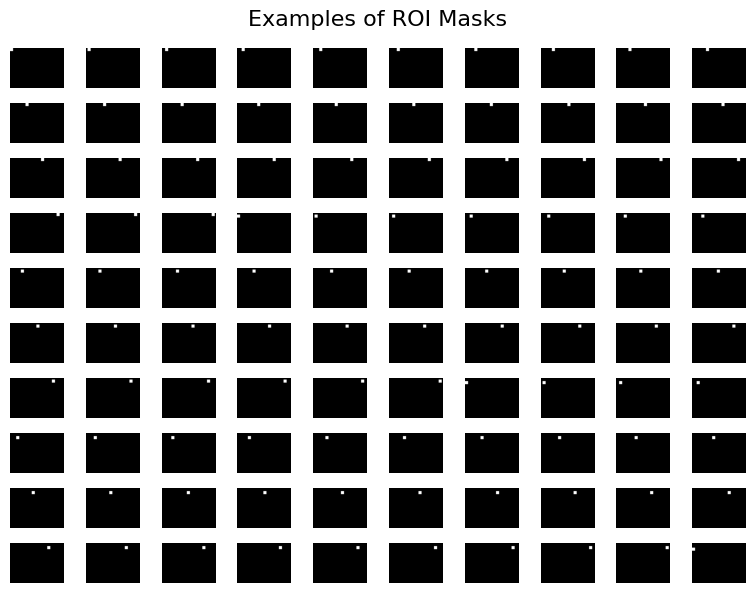

In [ ]:
def get_roi_sweep_masks(img_series, roi_size = 10, shift = 5, plot_roi = True):
    """
    Get masks, x, and y coordinates for ROIs swept across image
    """
    # Define ROI dimensions and shift
    # roi_size = 10  # 10x10 squares
    # shift = 5  # Shift by 5 pixels

    # Create an empty list to store masks
    masks = []
    x_roi = []
    y_roi = []

    # Generate ROI masks
    for y in range(0, img_series.shape[0] - roi_size + 1, shift):
        for x in range(0, img_series.shape[1] - roi_size + 1, shift):
            mask = np.zeros(img_series.shape[:-1], dtype=bool)
            mask[y:y + roi_size, x:x + roi_size] = True
            masks.append(mask)
            x_roi.append(x)
            y_roi.append(y)

    if plot_roi==True:
        # Example visualization of the first few masks
        # Define number of rows and columns
        rows, cols = 10, 10  # 4 rows, 8 columns (32 masks total)

        # Create subplots
        _, axes = plt.subplots(rows, cols, figsize=(12, 6))
        # Flatten axes for easy iteration
        axes = axes.flatten()

        # Plot masks
        for i, ax in enumerate(axes):
            if i < len(masks):
                ax.imshow(masks[i], cmap='gray')
                ax.axis('off')
            else:
                ax.axis('off')  # Hide empty subplots if any

        # Reduce spacing between subplots
        plt.subplots_adjust(wspace=-0.9, hspace=-0.01)  # Reduce horizontal and vertical spacing

        plt.suptitle("Examples of ROI Masks", fontsize=16)
        plt.tight_layout()
        plt.show()
    
    return np.array(masks),x,y

qcam_idx = 5
print(qcam_dB[qcam_idx])
img_series = experiment.qcam2img[qcam_dB[qcam_idx]]
masks,x_roi,y_roi = get_roi_sweep_masks(img_series, roi_size = 10, shift = 5, plot_roi = True)

In [ ]:
# apply to a given image series
def get_avg_in_rois(img_series, masks):
    # Initialize an array to store the average values
    roi_avg = np.zeros((len(masks), img_series.shape[2]))

    # Compute the average value within each ROI for each frame
    for i, mask in enumerate(masks):
        # Use broadcasting to apply the mask across all frames
        masked_data = img_series[mask, :]  # Shape will be (num_masked_pixels, 200)
        roi_avg[i, :] = masked_data.mean(axis=0)  # Average across pixels

    # Shape of avg_values: (number_of_masks, number_of_frames)
    print(img_series.shape)
    print(roi_avg.shape)

    return roi_avg

roi_avg = get_avg_in_rois(img_series, masks)

(130, 174, 200)
(825, 200)


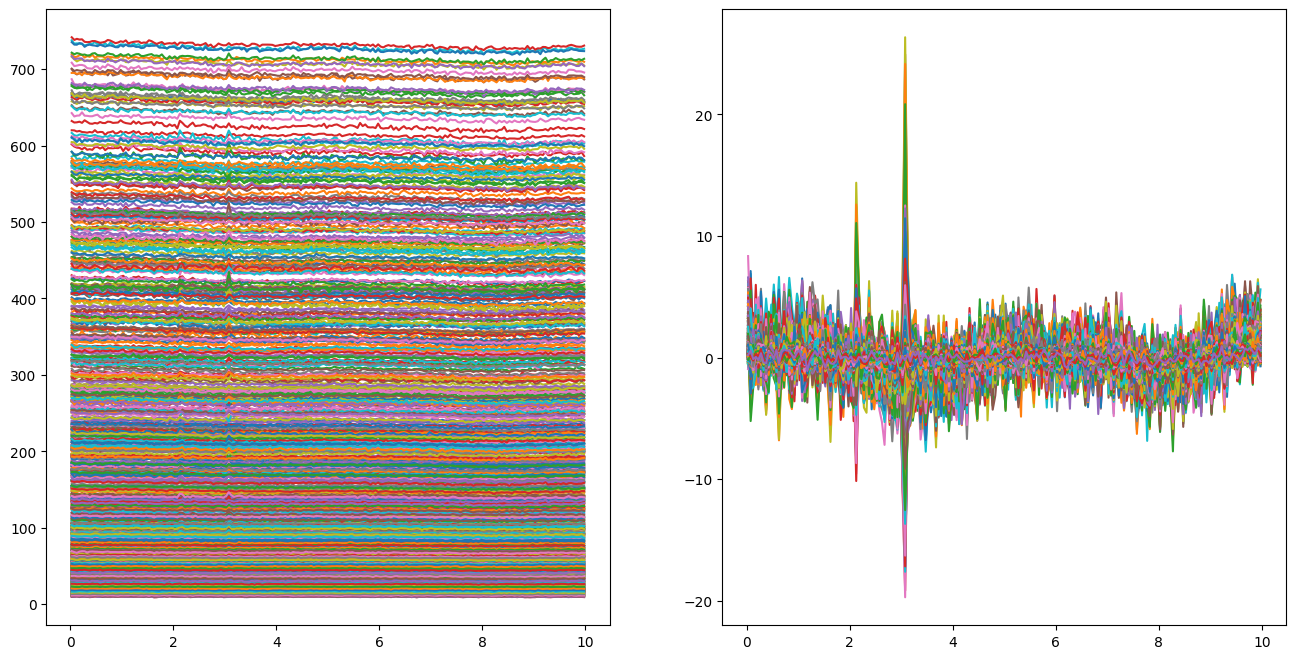

In [ ]:
import matplotlib.pyplot as plt
from lib.signalProcess import subtractLinFit

t = signalProcess.getTimeVec(img_series.shape[-1])

# filter to center around 0 fluorescnece intensity
roi_avg_filt = subtractLinFit(t, roi_avg, offset=False)[0]

fig,ax = plt.subplots(1,2,figsize=(16,8))
ax[0].plot(t,roi_avg.T)
ax[1].plot(t,roi_avg_filt.T)

## Hierarchical clustering 

In [212]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist

def cluster_roi(roi_trace, method='ward'):
    """
    Perform hierarchical clustering on roi responses
    
    Parameters:
    - roi_trace: Array of roi responses of shape [roi, time]
    - method: Linkage method for clustering
    
    Returns:
    - linkage_matrix: Hierarchical clustering linkage matrix
    """
    # Flatten the 2D roi data for clustering
    X = roi_trace.reshape(roi_trace.shape[0], -1)
    print(X.shape)
    # Compute pairwise distances
    distance_matrix = pdist(X, metric='euclidean')
    
    # Perform hierarchical clustering
    linkage_matrix = linkage(distance_matrix, method=method)
    
    return linkage_matrix

In [213]:
linkage_matrix = cluster_roi(roi_avg_filt)

# n_clusters = 4
# cluster_labels = fcluster(linkage_matrix, t=n_clusters, criterion='maxclust')

(825, 200)


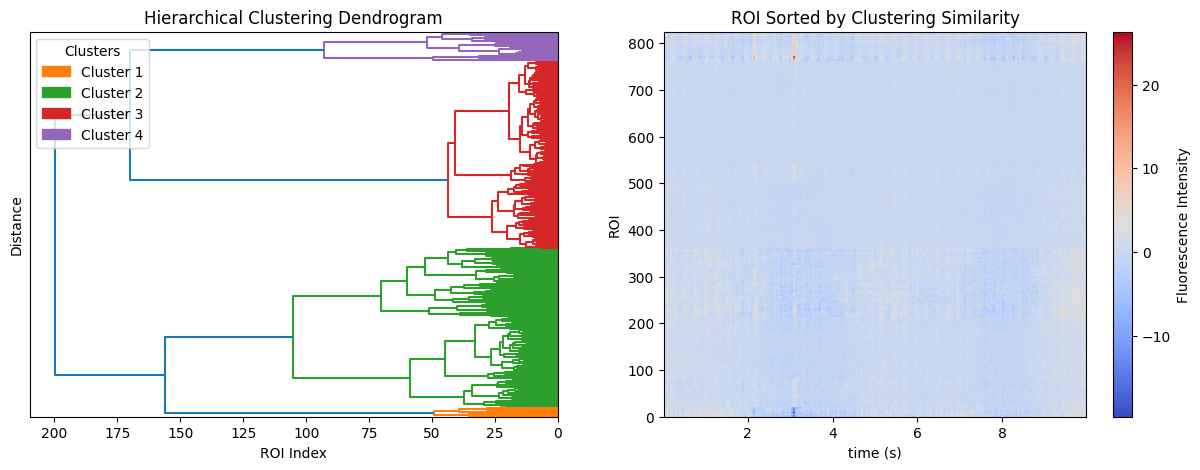

In [214]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def plot_hierarchical_cluster(linkage_matrix, t):
    # Generate the dendrogram without plotting to get metadata
    dendro = dendrogram(linkage_matrix, no_plot=True)
    
    # Extract leaf order and colors
    leaf_order = dendro['leaves']
    leaves_color_list = dendro['leaves_color_list']
    
    # Get the default Matplotlib color cycle
    color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
    
    # Get the unique colors and create a cluster-to-color mapping
    unique_colors = np.unique(leaves_color_list)
    # Create a mapping from cluster number to color
    color_map_legend = {i + 1: color for i, color in enumerate(unique_colors)}
    color_map = {str(val):{'cluster_id':k, 'cluster_color':color_cycle[k]} for k,val in color_map_legend.items()}
    
    # Plot the dendrogram
    sorted_roi = roi_avg_filt[leaf_order]
    
    # Create figure with subplots
    fig, ax = plt.subplots(1, 2, figsize=(15, 5))
    
    # Plot dendrogram
    dendrogram(
        linkage_matrix,
        orientation='left',
        leaf_font_size=5,
        no_labels=True,
        ax=ax[0]
    )
    ax[0].set_title('Hierarchical Clustering Dendrogram')
    ax[0].set_xlabel('ROI Index')
    ax[0].set_ylabel('Distance')
    # Create legend handles
    legend_handles = [mpatches.Patch(color=color_map_legend[i], label=f'Cluster {i}') for i in color_map_legend]
    ax[0].legend(handles=legend_handles, title="Clusters", loc='upper left')
    
    # Plot sorted ROI responses
    roi_trace_img = ax[1].imshow(sorted_roi, aspect='auto', extent=[t[0], t[-1], 0, sorted_roi.shape[0]], origin='lower', cmap='coolwarm')
    
    ax[1].set_title('ROI Sorted by Clustering Similarity')
    ax[1].set_xlabel('time (s)')
    ax[1].set_ylabel('ROI')
    fig.colorbar(roi_trace_img, label='Fluorescence Intensity', ax=ax[1])
    # ax[0].legend([1,2,3],loc='upper left')
    
    return color_map, np.array(leaves_color_list), np.array(leaf_order), 

color_map, leaves_color_list, leaf_order = plot_hierarchical_cluster(linkage_matrix, t)

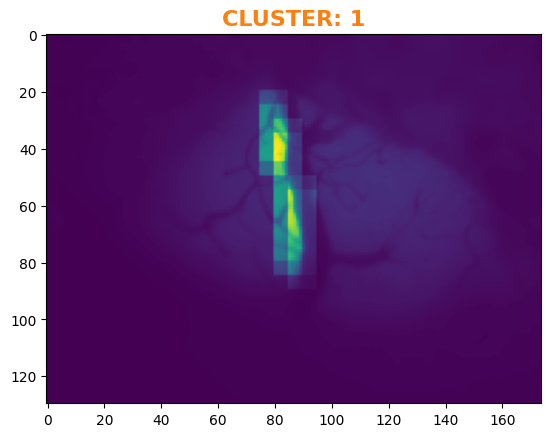

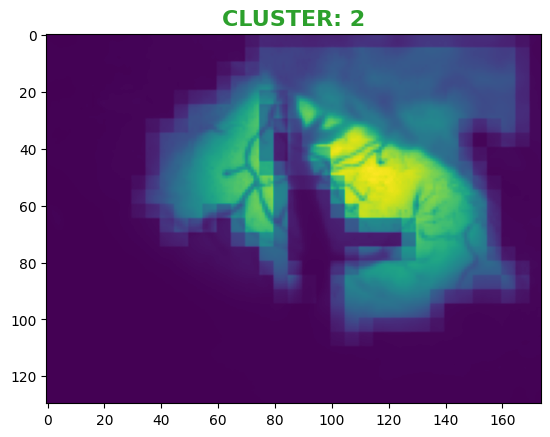

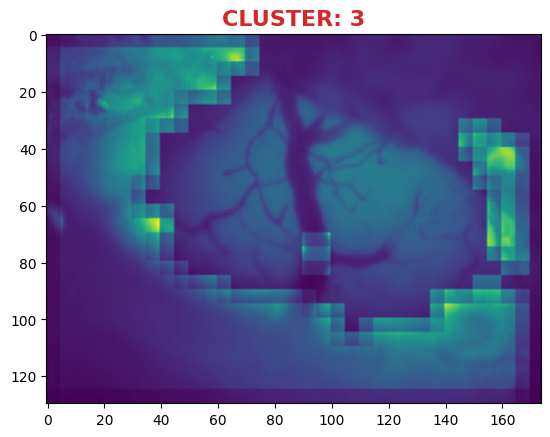

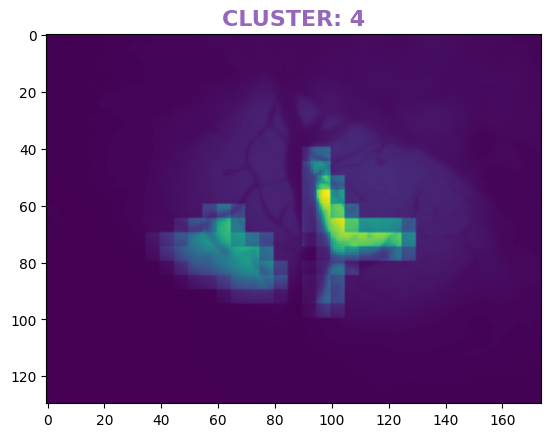

In [215]:
def plot_cluster_roi(img_series, masks, leaf_order, leaves_color_list):
    for cluster_color,cluster_d in color_map.items():
        _,ax = plt.subplots()
        ax.imshow((masks[leaf_order[leaves_color_list==cluster_color]].sum(axis=0)+0.5)*img_series.mean(axis=(-1)))
        ax.set_title(f"CLUSTER: {cluster_d['cluster_id']}", color=cluster_d['cluster_color'], fontsize=16, fontweight='bold')

plot_cluster_roi(img_series, masks, leaf_order, leaves_color_list)


# Hierarchical clustering: all-in-one

/media/DATA/MAK/GRISZ_02/AA0001/AA0001AAAA0044.qcamraw
(130, 174, 200)
(825, 200)
(825, 200)


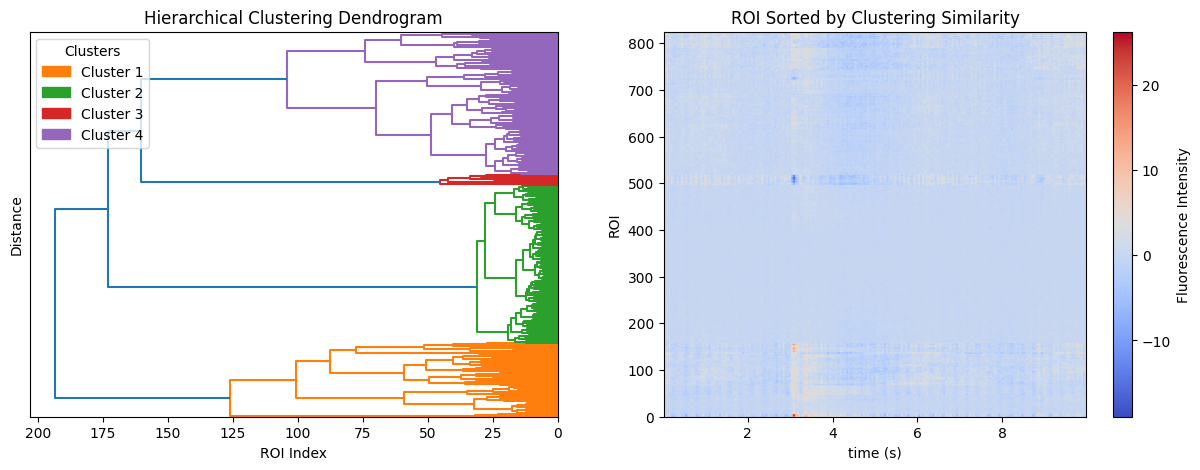

In [240]:
qcam_idx = 4
print(qcam_dB[qcam_idx])
img_series = experiment.qcam2img[qcam_dB[qcam_idx]]
masks,x_roi,y_roi = get_roi_sweep_masks(img_series, roi_size = 10, shift = 5, plot_roi = False)
# masks,x_roi,y_roi = get_roi_sweep_masks(img_series, roi_size = 8, shift = 4, plot_roi = False)

roi_avg = get_avg_in_rois(img_series, masks)
roi_avg_filt = subtractLinFit(t, roi_avg, offset=False)[0]
linkage_matrix = cluster_roi(roi_avg_filt)
color_map, leaves_color_list, leaf_order = plot_hierarchical_cluster(linkage_matrix, t)


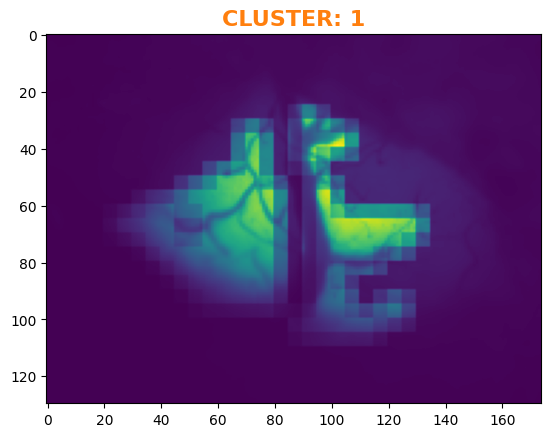

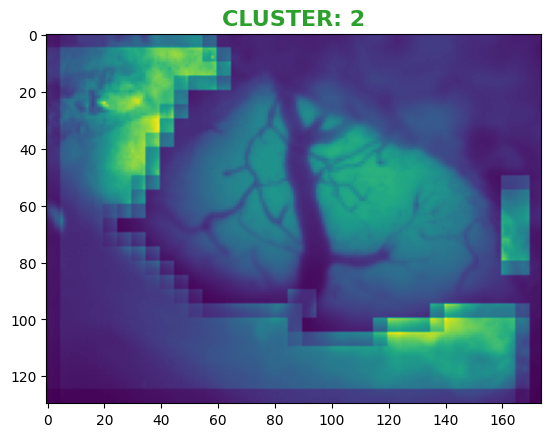

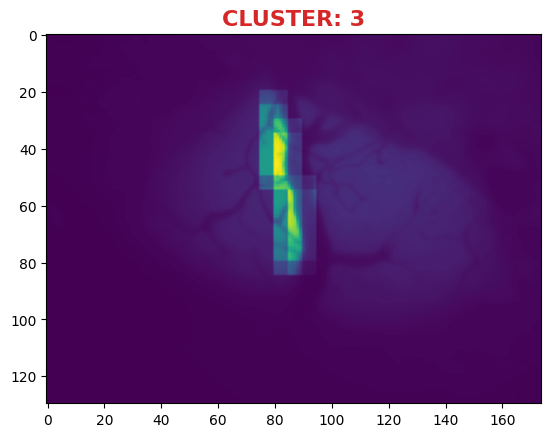

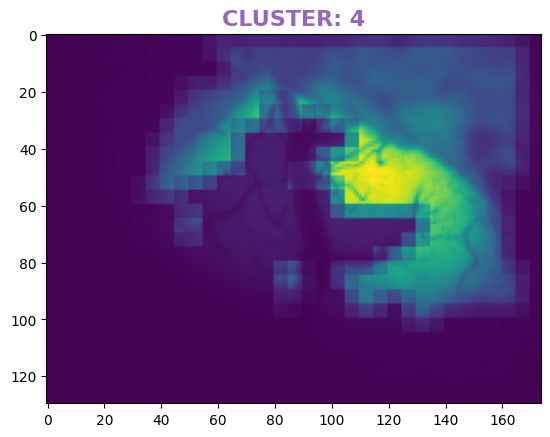

In [217]:
plot_cluster_roi(img_series, masks, leaf_order, leaves_color_list)
